# Portfolio Risk Analytics and Stress Testing


## 1. Project Setup

In this section, we set up the Python environment required for the analysis.

The key libraries used are:
- **yfinance**: to download historical stock price data
- **pandas**: for data manipulation and analysis
- **numpy**: for numerical computations

This step ensures that the environment is ready for data collection and further analysis.

In [2]:

# Import libraries
import yfinance as yf
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt


## 2. Data Collection

In this section, we collect historical stock price data for the selected companies.

We use **Yahoo Finance** as the data source via the "yfinance" library.

### Key steps:
- Define the list of stock tickers
- Download daily adjusted closing prices
- Use a robust method to handle potential data download issues

### Time Period:
January 2015 to December 2024

### Why adjusted prices?
Adjusted closing prices account for corporate actions such as dividends and stock splits, providing a more accurate representation of returns.

The downloaded data will be used in the next step to create monthly price series.

In [3]:
# Define stock tickers
tickers = ["AAPL", "MSFT", "TSLA", "AMZN", "NVDA"]

# Initialize empty DataFrame
price_data = pd.DataFrame()

# Download data ticker by ticker
for ticker in tickers:
    temp = yf.download(
        ticker,
        start="2015-01-01",
        end="2024-12-31",
        progress=False
    )["Close"]

    price_data[ticker] = temp

# Preview data
price_data.head()

/tmp/ipykernel_799/3394802202.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(
/tmp/ipykernel_799/3394802202.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(
/tmp/ipykernel_799/3394802202.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(
/tmp/ipykernel_799/3394802202.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(
/tmp/ipykernel_799/3394802202.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  temp = yf.download(


,AAPL,MSFT,TSLA,AMZN,NVDA
Date,,,,,
2015-01-02,24.214893,39.767685,14.620667,15.4260,0.482985
2015-01-05,23.532724,39.401993,14.006000,15.1095,0.474828
2015-01-06,23.534935,38.823669,14.085333,14.7645,0.460432
2015-01-07,23.864943,39.316944,14.063333,14.9210,0.459232
2015-01-08,24.781889,40.473576,14.041333,15.0230,0.476507


## 3. Data Preparation

In this section, we prepare the raw stock price data for portfolio analysis.

The downloaded data is in **daily frequency**, but for this project we use **monthly data**. Monthly data is more suitable for long-term portfolio analysis because it reduces short-term market noise and aligns better with realistic rebalancing decisions.

### Key steps:
- Convert daily prices into monthly prices using the last available trading day of each month
- Check for missing values
- Remove incomplete rows if needed

The final output of this step is a clean monthly price dataset that will be used to calculate stock returns.

In [4]:
# Convert daily prices to monthly prices using month-end values
monthly_prices = price_data.resample("M").last()

# Check for missing values
print("Missing values before cleaning:")
print(monthly_prices.isna().sum())

# Remove rows with missing values
monthly_prices = monthly_prices.dropna()

# Preview cleaned monthly data
monthly_prices.head()

Missing values before cleaning:
AAPL    0
MSFT    0
TSLA    0
AMZN    0
NVDA    0
dtype: int64


/tmp/ipykernel_799/2050354544.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_prices = price_data.resample("M").last()


,AAPL,MSFT,TSLA,AMZN,NVDA
Date,,,,,
2015-01-31,25.949120,34.358742,13.573333,17.726500,0.460672
2015-02-28,28.564177,37.558228,13.556000,19.007999,0.531330
2015-03-31,27.668072,34.825943,12.584667,18.605000,0.504114
2015-04-30,27.828171,41.660954,15.070000,21.089001,0.534703
2015-05-31,29.089876,40.397198,16.719999,21.461500,0.535484


In [5]:
# Save monthly prices to CSV
monthly_prices.to_csv("data/processed/monthly_prices.csv")

# Validate dataset structure
print("Dataset Info:")
print(monthly_prices.info())

print("\nSummary Statistics:")
print(monthly_prices.describe())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 120 entries, 2015-01-31 to 2024-12-31
Freq: ME
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    120 non-null    float64
 1   MSFT    120 non-null    float64
 2   TSLA    120 non-null    float64
 3   AMZN    120 non-null    float64
 4   NVDA    120 non-null    float64
dtypes: float64(5)
memory usage: 5.6 KB
None

Summary Statistics:
             AAPL        MSFT        TSLA        AMZN        NVDA
count  120.000000  120.000000  120.000000  120.000000  120.000000
mean    94.558189  181.407357  118.335261  101.642100   21.176108
std     66.401917  122.977055  116.879320   53.991200   32.733286
min     21.230284   34.358742   12.344000   17.726500    0.460672
25%     35.240407   65.377244   17.437333   48.872499    3.513580
50%     65.236248  149.601028   31.411000   95.503750    6.644822
75%    151.618172  272.665009  225.516670  153.833878   21.088668
m

## 4. Return Calculation

In this section, we calculate monthly returns from the price data. Returns measure how much each stock has gained or lost over time and form the foundation for portfolio analysis.



In [6]:
# Calculate monthly returns
returns = monthly_prices.pct_change()
returns = returns.dropna()

# Preview returns
returns.head()
returns.describe()

,AAPL,MSFT,TSLA,AMZN,NVDA
count,119.000000,119.000000,119.000000,119.000000,119.000000
mean,0.022377,0.023121,0.043765,0.025231,0.057845
std,0.079961,0.061855,0.180616,0.088603,0.134863
min,-0.181198,-0.109267,-0.367334,-0.237525,-0.320274
25%,-0.032977,-0.013298,-0.072650,-0.032743,-0.024564
50%,0.023652,0.024652,0.011807,0.025468,0.056197
75%,0.080482,0.061529,0.126376,0.074850,0.142574
max,0.216569,0.196262,0.741452,0.270596,0.385446


## 5. Portfolio Construction

### 5.1 Equal Weight Portfolio

In this section, we construct an equal-weight portfolio.

An equal-weight portfolio assigns the same weight to each asset in the portfolio. With 5 stocks, each stock receives a 20% allocation.

### Why use equal weight?
- Simple and transparent benchmark
- Does not rely on forecasts or assumptions
- Commonly used as a baseline for comparison

### Key steps:
- Assign equal weights to all stocks
- Calculate portfolio returns as the weighted average of individual stock returns

This portfolio will serve as a benchmark against the strategy-based portfolio in later sections.

In [7]:
# Number of assets
num_assets = len(returns.columns)

# Assign equal weights (e.g., 1/5 = 0.2 each)
weights_equal = np.array([1/num_assets] * num_assets)

# Calculate portfolio returns
portfolio_equal_returns = returns.dot(weights_equal)

# Convert to DataFrame for consistency
portfolio_equal_returns = pd.DataFrame(portfolio_equal_returns, columns=["Equal_Weight_Portfolio"])

# Preview results
portfolio_equal_returns.head()

,Equal_Weight_Portfolio
Date,
2015-02-28,0.083659
2015-03-31,-0.049640
2015-04-30,0.118746
2015-05-31,0.028723
2015-06-30,-0.021080


### 5.2 Momentum Portfolio

In this section, we construct a momentum-based portfolio.

The momentum strategy is based on the idea that stocks that have performed well in the past tend to continue performing well in the short to medium term.

### Strategy Logic:
- Calculate past returns over a lookback period (e.g., 3 months)
- Assign higher weights to stocks with higher past returns
- Rebalance the portfolio monthly

### Why momentum?
- Widely used in asset management
- Supported by academic research
- Helps capture trends in the market

This portfolio will be compared with the equal-weight portfolio to evaluate performance and risk differences.

In [11]:
# Define lookback period
lookback = 3
top_n = 2

# Calculate momentum signal using past 3-month average returns
momentum_signal = returns.rolling(window=lookback).mean()

# Shift signal by 1 month to avoid look-ahead bias
momentum_signal = momentum_signal.shift(1)

# Drop missing rows
momentum_signal = momentum_signal.dropna()
returns_momentum = returns.loc[momentum_signal.index]

# Create empty weights DataFrame
weights_momentum = pd.DataFrame(
    0.0, index=momentum_signal.index, columns=momentum_signal.columns
    )

# Assign equal weights to top N stocks each month
for date in momentum_signal.index:
    top_stocks = momentum_signal.loc[date].nlargest(top_n).index
    weights_momentum.loc[date, top_stocks] = 1 / top_n

# Calculate momentum portfolio returns
portfolio_momentum_returns = (weights_momentum * returns_momentum).sum(axis=1)

# Convert to DataFrame
portfolio_momentum_returns = pd.DataFrame(
    portfolio_momentum_returns,
    columns=["Momentum_Portfolio"]
)

# Add Transaction Cost
transaction_cost = 0.001  # 0.1% per rebalance
portfolio_momentum_returns["Momentum_Portfolio"] = (
    portfolio_momentum_returns["Momentum_Portfolio"] - transaction_cost
)

# Preview
portfolio_momentum_returns.head()

,Momentum_Portfolio
Date,
2015-05-31,-0.007336
2015-06-30,0.039470
2015-07-31,0.112624
2015-08-31,-0.054798
2015-09-30,0.046290


**Combine Portfolio Returns for Comparison**

We combine the return series of both portfolios into a single dataset to create a clean comparison framework for the rest of the analysis.


In [12]:
# Combine both portfolio return series
portfolio_returns = pd.concat(
    [portfolio_equal_returns, portfolio_momentum_returns],
    axis=1
)

# Drop rows with missing values to align both portfolios
portfolio_returns = portfolio_returns.dropna()

# Preview combined portfolio returns
portfolio_returns.head()

,Equal_Weight_Portfolio,Momentum_Portfolio
Date,,
2015-05-31,0.028723,-0.007336
2015-06-30,-0.021080,0.039470
2015-07-31,0.048824,0.112624
2015-08-31,-0.020836,-0.054798
2015-09-30,0.017424,0.046290


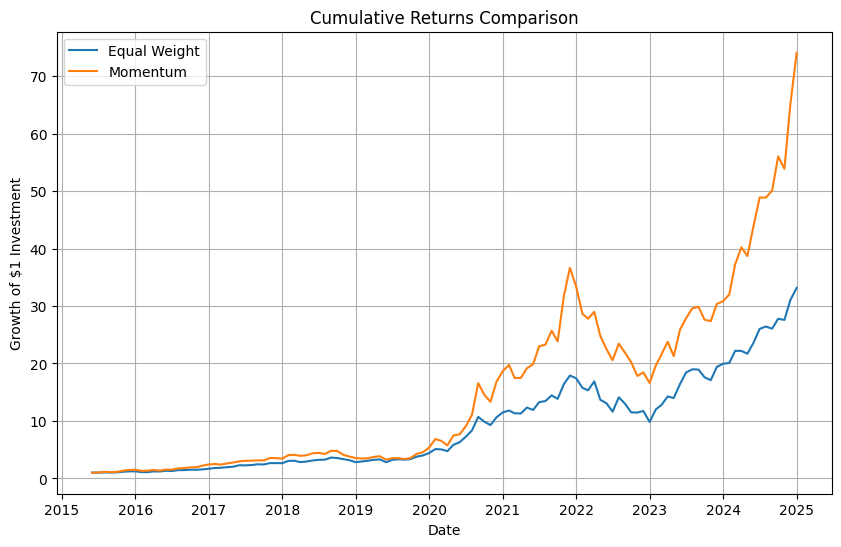

In [13]:
# Calculate cumulative returns
cumulative_returns = (1 + portfolio_returns).cumprod()

# Plot cumulative returns
plt.figure(figsize=(10, 6))
plt.plot(cumulative_returns.index, cumulative_returns["Equal_Weight_Portfolio"], label="Equal Weight")
plt.plot(cumulative_returns.index, cumulative_returns["Momentum_Portfolio"], label="Momentum")

# Titles and labels
plt.title("Cumulative Returns Comparison")
plt.xlabel("Date")
plt.ylabel("Growth of $1 Investment")

# Legend and grid
plt.legend()
plt.grid()

plt.show()

## 6. Performance Metrics

In this section, we evaluate the performance of both portfolios using standard portfolio analysis metrics.

### Metrics included:
- **Annual Return**: average yearly growth rate of the portfolio
- **Annual Volatility**: yearly risk based on monthly return fluctuations
- **Sharpe Ratio**: return earned per unit of risk
- **Maximum Drawdown**: largest peak-to-trough decline in portfolio value

### Why these metrics matter
These measures help assess not only how much a portfolio earns, but also how much risk is taken to achieve those returns.

This provides a more complete comparison between the equal-weight and momentum strategies.

In [14]:
# Set annual risk-free rate
risk_free_rate = 0.02

# Convert annual risk-free rate to monthly
monthly_rf = risk_free_rate / 12

# Function to calculate performance metrics
def calculate_metrics(return_series):
    annual_return = (1 + return_series.mean())**12 - 1
    annual_volatility = return_series.std() * np.sqrt(12)
    sharpe_ratio = (return_series.mean() - monthly_rf) / return_series.std() * np.sqrt(12)

    cumulative = (1 + return_series).cumprod()
    running_max = cumulative.cummax()
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()

    return pd.Series({
        "Annual Return": annual_return,
        "Annual Volatility": annual_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Maximum Drawdown": max_drawdown
    })

# Apply function to both portfolios
performance_metrics = portfolio_returns.apply(calculate_metrics)

# Transpose for better readability
performance_metrics = performance_metrics.T

# Display results
performance_metrics

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown
Equal_Weight_Portfolio,0.494374,0.291486,1.332848,-0.451340
Momentum_Portfolio,0.666086,0.384919,1.302845,-0.546658


## 7. Risk Analysis

### 7.1 Drawdown Analysis

In this section, we analyse the drawdowns of both portfolios.

#### What is drawdown?
Drawdown measures the decline from a portfolio’s previous peak to its lowest point before recovering.

#### Why is it important?
- It captures downside risk
- Helps understand how much an investor could lose
- More intuitive than volatility for real-world investors

#### Key steps:
- Calculate cumulative returns
- Identify running maximum (peak value)
- Compute drawdowns as percentage decline from peak

This analysis helps compare how each portfolio behaves during market downturns.

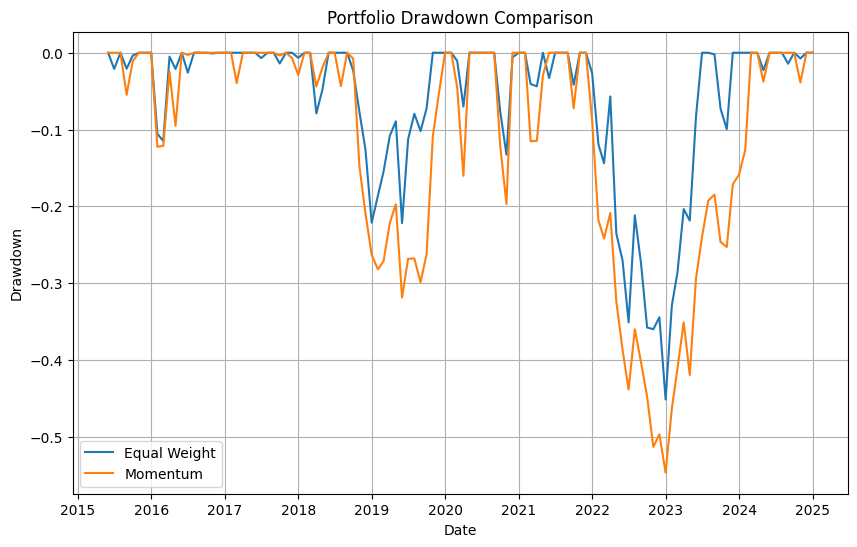

In [15]:
# Calculate drawdowns
cumulative = (1 + portfolio_returns).cumprod()
running_max = cumulative.cummax()
drawdown = (cumulative - running_max) / running_max

# Plot drawdowns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(drawdown.index, drawdown["Equal_Weight_Portfolio"], label="Equal Weight")
plt.plot(drawdown.index, drawdown["Momentum_Portfolio"], label="Momentum")

plt.title("Portfolio Drawdown Comparison")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.legend()
plt.grid()

plt.show()

### 7.2 Value at Risk (VaR)

In this section, we estimate the Value at Risk (VaR) for both portfolios.

#### What is VaR?
Value at Risk measures the maximum expected loss over a given time period at a specified confidence level.

For example:
A 95% VaR of -5% means there is a 95% probability that the portfolio will not lose more than 5% in a given month.

#### Approach used:
- Historical simulation method
- Based on the distribution of past returns

#### Why VaR is important:
- Widely used in risk management
- Helps quantify potential downside risk
- Useful for comparing risk across portfolios

In [17]:
# Define confidence level
confidence_level = 0.05  # 95% VaR

# Calculate VaR
VaR = portfolio_returns.quantile(confidence_level)

# Convert to clean DataFrame
VaR = VaR.to_frame(name="VaR (95%)")

# Display
VaR

,VaR (95%)
Equal_Weight_Portfolio,-0.106559
Momentum_Portfolio,-0.121019


### 7.3 Conditional Value at Risk (CVaR)

In this section, we calculate Conditional Value at Risk (CVaR), also known as Expected Shortfall.

#### What is CVaR?
CVaR measures the **average loss** in the worst-case scenarios beyond the VaR threshold.

For example:
If VaR tells us the cutoff for the worst 5% of returns, CVaR tells us the average loss within that worst 5%.

#### Why is CVaR important?
- Captures tail risk better than VaR
- Shows how severe losses can be in extreme conditions
- Useful for comparing portfolios during stress periods

This makes CVaR a stronger measure of downside risk than VaR alone.

In [18]:
# Calculate CVaR (Expected Shortfall)
CVaR = portfolio_returns.apply(
    lambda x: x[x <= x.quantile(0.05)].mean()
)

# Convert to DataFrame
CVaR = CVaR.to_frame(name="CVaR (95%)")

# Display
CVaR

,CVaR (95%)
Equal_Weight_Portfolio,-0.138693
Momentum_Portfolio,-0.137258


In [19]:
# Combine VaR and CVaR into one table
risk_summary = pd.concat([VaR, CVaR], axis=1)

# Format as percentages for readability
risk_summary = risk_summary * 100

# Round values
risk_summary = risk_summary.round(2)

# Display
risk_summary

,VaR (95%),CVaR (95%)
Equal_Weight_Portfolio,-10.66,-13.87
Momentum_Portfolio,-12.10,-13.73


## 8. Portfolio Comparison

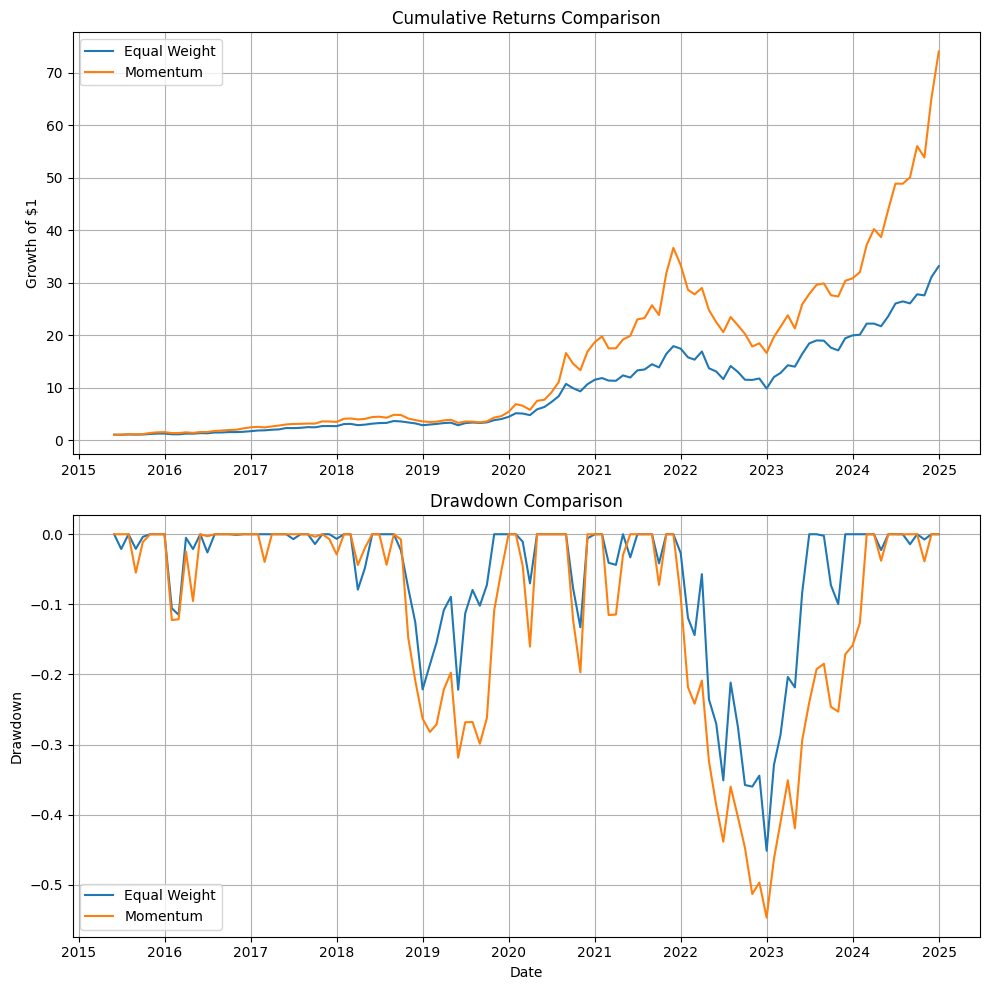

In [20]:
# Recalculate cumulative returns (for safety)
cumulative_returns = (1 + portfolio_returns).cumprod()

# Recalculate drawdowns
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max

# Create subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 10))

# --- Plot 1: Cumulative Returns ---
axes[0].plot(cumulative_returns.index, cumulative_returns["Equal_Weight_Portfolio"], label="Equal Weight")
axes[0].plot(cumulative_returns.index, cumulative_returns["Momentum_Portfolio"], label="Momentum")
axes[0].set_title("Cumulative Returns Comparison")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[0].grid()

# --- Plot 2: Drawdowns ---
axes[1].plot(drawdown.index, drawdown["Equal_Weight_Portfolio"], label="Equal Weight")
axes[1].plot(drawdown.index, drawdown["Momentum_Portfolio"], label="Momentum")
axes[1].set_title("Drawdown Comparison")
axes[1].set_ylabel("Drawdown")
axes[1].set_xlabel("Date")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

## 9. Final Summary Table

This table provides a consolidated view of performance and risk metrics for both portfolios.

### Metrics included:
- Annual Return
- Annual Volatility
- Sharpe Ratio
- Value at Risk (VaR)
- Conditional Value at Risk (CVaR)

This summary allows for a direct comparison of return, risk, and downside exposure across strategies.

In [21]:
# Combine performance and risk metrics
# Merge all metrics
final_summary = performance_metrics.copy()

# Add VaR and CVaR (convert to %)
final_summary["VaR (95%)"] = VaR["VaR (95%)"] * 100
final_summary["CVaR (95%)"] = CVaR["CVaR (95%)"] * 100

# Convert performance metrics to %
final_summary["Annual Return"] *= 100
final_summary["Annual Volatility"] *= 100
final_summary["Maximum Drawdown"] *= 100

# Round values
final_summary = final_summary.round(2)

# Display
final_summary

,Annual Return,Annual Volatility,Sharpe Ratio,Maximum Drawdown,VaR (95%),CVaR (95%)
Equal_Weight_Portfolio,49.44,29.15,1.33,-45.13,-10.66,-13.87
Momentum_Portfolio,66.61,38.49,1.30,-54.67,-12.10,-13.73


## 10. Key Insights and Conclusion

This project analysed the performance and risk characteristics of two portfolio strategies: an equal-weight portfolio and a momentum-based portfolio.

### Key Findings

**Performance**

The momentum portfolio delivered significantly higher cumulative returns compared to the equal-weight portfolio. This indicates that allocating capital based on recent performance trends can enhance returns.

**Volatility and Risk**

The momentum strategy exhibited higher volatility, reflecting greater fluctuations in returns. In contrast, the equal-weight portfolio showed more stable performance over time.

**Risk-Adjusted Performance**

Despite lower absolute returns, the equal-weight portfolio achieved a slightly higher Sharpe ratio. This suggests that it provided better returns per unit of risk compared to the momentum strategy.

**Drawdown Analysis**

The momentum portfolio experienced deeper and more frequent drawdowns, indicating higher downside risk during market corrections.

**Value at Risk (VaR)**

The momentum portfolio had a more negative VaR, indicating a higher potential loss under normal market conditions.

**Conditional Value at Risk (CVaR)**

Both portfolios showed similar CVaR values, suggesting that extreme losses during severe market conditions are comparable across strategies.

### Conclusion

The results highlight a clear trade-off between return and risk:

- The momentum strategy enhances returns but increases exposure to volatility and downside risk.
- The equal-weight portfolio offers more stable and efficient performance on a risk-adjusted basis.

Overall, investors should consider both return objectives and risk tolerance when selecting a portfolio strategy. A balanced approach may involve combining both strategies or incorporating risk controls to improve performance consistency.

### Limitations

- The analysis is based on a small set of large-cap US stocks
- Transaction costs are simplified and not dynamically modelled
- Results may vary under different market conditions or time periods

### Future Improvements

- Expand the stock universe for better diversification
- Implement dynamic transaction cost modelling
- Incorporate additional strategies such as low-volatility or mean-reversion
- Apply machine learning models for return prediction and allocation

---

This project demonstrates the ability to construct portfolios, evaluate performance, and analyse risk using quantitative methods, which are essential skills in portfolio management and investment analysis.